Denoising by Sobolev and Total Variation Regularization
=======================================================

*Important:* Please read the [installation page](http://gpeyre.github.io/numerical-tours/installation_python/) for details about how to install the toolboxes.

- This numerical tour explores the use of variational minimization to perform denoising. 
- It consider the Sobolev and the Total Variation regularization functional (priors).

In [7]:
import sys, os

# chemin ABSOLU vers le dossier qui contient nt_toolbox
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *

In [9]:
from __future__ import division
import nt_toolbox as nt
#from nt_solutions import denoisingsimp_4_denoiseregul as solutions
%matplotlib inline
%load_ext autoreload
%autoreload 2

#### `Prior and Regularization`
Pour une image $f$ donnée $J(f) \in \mathbb{R}$ associe un score qui est supposé être faible pour l’image d’intérêt. 
Le débruitage d’une image y est obtenu par une minimisation variationnelle qui combine un ajustement aux données (généralement via une norme $L^2$ ) et l’a priori.
$$ \min_f \frac{1}{2}\|y-f\|^2 + \lambda J(f) $$
 - Si $J(f)$ est une fonction convexe de $f$, alors le minimum existe et il est unique. 

Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

Si $J(f)$ est un fonction continue de l'image $f$, un minimiseur de ce problème peut être calculé par descente de gradient. Cela définit une suite d’images $f^{(\ell)}$ indexed by $\ell \in \mathbb{N}$
tel que : 
$$ f^{(\ell+1)} = f^{(\ell)} + \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right). $$


Notons que $f^{(\ell)}$ converge lorsque $\ell \rightarrow +\infty$ vers une solution du problème
$\large \tau$ requiert d'être suffisamment faible, plus précisément, si la fonction $J$ est deux fois différenciable
$$ \tau < \frac{2}{1 + \lambda \max_f \|D^2 J(f)\|}. $$

`«A priori de Sobolev»`
 - L’a priori d’image de Sobolev est un a priori quadratique, c’est‑à‑dire une (pseudo-)norme de Hilbert.
 - « Nous chargeons d’abord une image propre (sans bruit). »

In [30]:
n = 256
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)
print(f0.shape)
# normalise l'image, pour l’affichage et les paramètres (bruit, λ, etc.).
f0 = rescale(f0)

(256, 256)


Pour une fonction $f$ continue et régulière, définit par : $J(f) = \int \|\nabla f(x)\|^2 d x $
Où le gradient au point $x$ et définit tel que : $\nabla f(x) = \large \left(  \frac{\partial f(x)}{\partial x_1},\frac{\partial f(x)}{\partial x_2} \right)$
Une image discrète pixélisée $f \in \mathbb{R}^N$ où $N=n \times n$ le nombre de pixel $\nabla f(x) \in \mathbb{R}^2$ calculé à l’aide de différences finies.

In [32]:
Gr = grad(f0)
print(Gr.shape)

(256, 256, 2)


Calcule de la norme euclidienne du gradient $d(x) = \|\nabla f(x)\| $ en chaque pixel : $d(i,j)= \sqrt{(∂_x f(i,j))^2 +(∂_yf(i,j))^2}$

In [35]:
d = np.sqrt(np.sum(Gr**2, axis=2))
print(d.shape)

(256, 256)


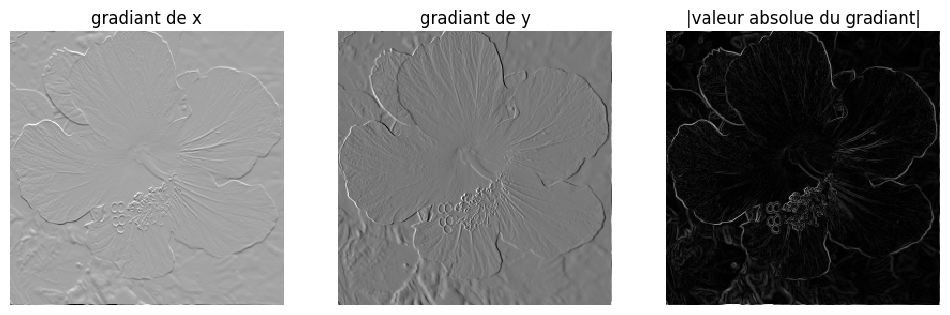

In [49]:
plt.figure(figsize=(12, 4))
imageplot(Gr[:, :, 0], 'gradiant de x', [1, 3, 1])
imageplot(Gr[:, :, 1], 'gradiant de y', [1, 3, 2])
imageplot(d,         '|valeur absolue du gradiant|', [1, 3, 3])

« La norme de Sobolev est la norme au carré $L^2$ du gradiant $\nabla f \in\mathbb{R}^{N \times 2}$.

In [44]:
sob = np.sum(d**2)
sob

229.17343184673206

### `Débruitage, régularisation de type chaleur`
 - `La régularisation de type chaleur, lisse l’image à l’aide d’un filtre passe‑bas`. 
 - `Augmenter la valeur de $∣\sigma∣$ augmente la quantité de lissage`. 
 - `On ajoute du bruit à l’image originale`.
 
    - $f_0$ image réelle 
    - $y$ image $f_0$ bruitée

In [50]:
sigma = .1
y = f0 + np.random.randn(n, n)*sigma

$f^{\star}$ `la régularisation de Sobolev peut-être calculé en utilisant la transformée de Fourier` : 
- $ \hat f^{\star}(\omega) = \large \frac{\hat y(\omega)}{ 1+\lambda S(\omega) } \quad$ $\text{où}\quad S(\omega)=\|\omega\|^2. $

   - Ceci montre que $f^{\star}$ est un filtre de $y$.
   - Utile pour plus tard : Transformée de Fourier des observations.

In [54]:
# la régularisation de Sobolev 
yF = np.fft.fft2(y)

`Calculer la pénalité d’a priori de Sobolev S (la ramener dans l’intervalle [0,1])`
`Pénalité d’a priori de Sobolev S`
 - ce n’est pas une image 
 - c'est la grille de fréquences qu’on met dans le dénominateur du filtre de chaleur
 - elle se calcule ainsi (en 2D, taille n×n)

In [ ]:
n = 256  # par exemple
# Grille de fréquences 1D (ordre "FFT", zéro au bord [0,.,127,-128,.,-1])
x = np.concatenate((np.arange(0, n//2), np.arange(-n//2, 0)))
Y, X = np.meshgrid(x, x)
S = (X**2 + Y**2) * (2 / n)**2

Regularization parameter: Perform the denoising by filtering.
$$ \tau < \frac{2}{1 + \lambda \max_f \|D^2 J(f)\|}. $$

In [ ]:
lambd = 20
fSob = np.real(np.fft.ifft2(yF / (1 + lambd * S)))

Display.

In [ ]:
imageplot(clamp(fSob))

__Exercise 1__

Compute the solution for several value of $\lambda$ and choose the
optimal |lambda| and the corresponding optimal denoising |fSob0|.
You can increase progressively lambda and reduce
considerably the number of iterations.
lot

In [ ]:
solutions.exo1()

In [ ]:
## Insert your code here.

Display best "oracle" denoising result.

In [ ]:
esob = snr(f0, fSob0);  enoisy = snr(f0, y)

imageplot(clamp(y), strcat(['Noisy ' num2str(enoisy, 3) 'dB']), 1, 2, 1)
imageplot(clamp(fSob0), strcat(['Sobolev regularization ' num2str(esob, 3) 'dB']), 1, 2, 2)

Total Variation Prior
---------------------
The total variation is a Banach norm.
On the contrary to the Sobolev norm, it is able to take into account step edges.


The total variation of a smooth image $f$ is defined as
$$J(f)=\int \|\nabla f(x)\| d x$$


It is extended to non-smooth images having step discontinuities.


The total variation of an image is also equal to the total length of its level sets.
$$J(f)=\int_{-\infty}^{+\infty} L( S_t(f) ) dt$$


Where $S_t(f)$ is the level set at $t$ of the image $f$
$$S_t(f)=\{ x \backslash f(x)=t \}$$

__Exercise 2__

Compute the total variation of |f0|.
isplay

In [ ]:
solutions.exo2()

In [ ]:
## Insert your code here.

The Gradient of the TV norm is
$$ \text{Grad}J(f) = \text{div}\left( \frac{\nabla f}{\|\nabla f\|} \right) . $$


The gradient of the TV norm is not defined if at a pixel $x$
one has $\nabla f(x)=0$. This means that the TV norm is difficult to
minimize, and its gradient flow is not well defined.


To define a gradient flow, we consider instead a smooth TV norm
$$J_\epsilon(f) = \int \sqrt{ \varepsilon^2 + \| \nabla f(x) \|^2 } d x$$


This corresponds to replacing $\|u\|$ by $ \sqrt{\varepsilon^2 + \|u\|^2} $
which is a smooth function.


We display (in 1D) the smoothing of the absolute value.

In [ ]:
u = linspace(-5, 5)'

subplot(2, 1, 1); hold('on')
plot(u, abs(u), 'b')
plot(u, sqrt(.5^2 + u.^2), 'r')
title('\epsilon = 1/ 2'); axis('square')
subplot(2, 1, 2); hold('on')
plot(u, abs(u), 'b')
plot(u, sqrt(1^2 + u.^2), 'r')
title('\epsilon = 1'); axis('square')

The Gradient of the smoothed TV norm is
$$ \text{Grad}J(f) = \text{div}\left( \frac{\nabla f}{\sqrt{\varepsilon^2 + \|\nabla f\|^2}} \right) . $$


When $\varepsilon$ increases, the smoothed TV gradient approaches the
Laplacian (normalized by $1/\varepsilon$).

In [ ]:
epsilon_list = [1e-9 1e-2 1e-1 .5]

for i in 1: length(epsilon_list):
    G = div(Gr ./ repmat(sqrt(epsilon_list(i)^2 + d.^2) , [1 1 2]))
    imageplot(G, strcat(['epsilon = ' num2str(epsilon_list(i))]), 2, 2, i)

Total Variation Regulariation for Denoising
-------------------------------------------
Total variation regularization was introduced by Rudin, Osher and Fatemi,
to better respect the edge of image than linear filtering.


We set a small enough regularization parameter.

In [ ]:
epsilon = 1e-2

Define the regularization parameter $\lambda$.

In [ ]:
lambda = .1

The step size for diffusion should satisfy:
$$ \tau < \frac{2}{1 + \lambda 8 / \varepsilon} . $$

In [ ]:
tau = 2 / (1 + lambda * 8 / epsilon)

Initialization of the minimization.

In [ ]:
fTV = y

Compute the gradient of the smoothed TV norm.

In [ ]:
Gr = grad(fTV)
d = sqrt(sum3(Gr.^2, 3))
G = -div(Gr ./ repmat(sqrt(epsilon^2 + d.^2) , [1 1 2]))

One step of descent.

In [ ]:
fTV = fTV - tau*(y-fTV + lambda* G)

__Exercise 3__

Compute the gradient descent and monitor
the minimized energy.

In [ ]:
solutions.exo3()

In [ ]:
## Insert your code here.

Display the image.

In [ ]:
imageplot(fTV)

__Exercise 4__

Compute the solution for several value of $\lambda$ and choose the
optimal $\lambda$ and the corresponding optimal denoising |fSob0|.
You can increase progressively $\lambda$ and reduce
considerably the number of iterations.

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.

Display best "oracle" denoising result.

In [ ]:
etvr = snr(f0, fTV0)

imageplot(clamp(y), strcat(['Noisy ' num2str(enoisy, 3) 'dB']), 1, 2, 1)
imageplot(clamp(fTV0), strcat(['TV regularization ' num2str(etvr, 3) 'dB']), 1, 2, 2)

__Exercise 5__

Compare the TV denoising with a hard thresholding in a translation
invariant tight frame of wavelets.

In [ ]:
solutions.exo5()

In [ ]:
## Insert your code here.